## EXPLORING DATA

In [ ]:
import pandas as pd
import numpy as np
import re
import pandas as pd
import re
import plotly.express as px
from collections import Counter
import matplotlib.pyplot as plt
!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC

In [2]:
df = pd.read_csv("emails.csv")
df = df.drop('id', axis=1)

In [3]:
df.head()

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
df.shape

(18650, 2)

In [5]:
df.dtypes

Email Text    object
Email Type    object
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Email Text  18634 non-null  object
 1   Email Type  18650 non-null  object
dtypes: object(2)
memory usage: 291.5+ KB


In [7]:
df.describe()

,Email Text,Email Type
count,18634,18650
unique,17537,2
top,empty,Safe Email
freq,533,11322


In [8]:
df['Email Type'].value_counts()

Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

In [9]:
df.isnull().sum()

Email Text    16
Email Type     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1111)

## PRE-PROCESSING DATA

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
def preprocess_text(text):
    # Remove hyperlinks
    text = re.sub(r'http\S+', '', text)

    # Remove punctuations
    text = re.sub(r'[^\w\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df["Email Text"] = df["Email Text"].fillna("").astype(str).apply(preprocess_text)

## EDA

In [ ]:
df1 = df.copy()

# Tokenize function
def tokenize(text):
    # keep only letters
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    return words

# Separate safe and phishing emails
safe_text = " ".join(df1[df1["Email Type"] == "Safe Email"]["Email Text"])
phish_text = " ".join(df1[df1["Email Type"] == "Phishing Email"]["Email Text"])

safe_words = tokenize(safe_text)
phish_words = tokenize(phish_text)

#  Count words
safe_counter = Counter(safe_words)
phish_counter = Counter(phish_words)

#  Get all unique words
all_unique_words = set(safe_counter.keys()).union(set(phish_counter.keys()))

print("Total unique words:", len(all_unique_words))

comparison_data = []

for word in all_unique_words:
    comparison_data.append({
        "word": word,
        "safe_count": safe_counter.get(word, 0),
        "phish_count": phish_counter.get(word, 0)
    })

comparison_df = pd.DataFrame(comparison_data)

# Remove very rare words (optional but recommended)
comparison_df = comparison_df[
    (comparison_df["safe_count"] + comparison_df["phish_count"]) > 10
]

# Sort by phishing frequency
comparison_df = comparison_df.sort_values(by="phish_count", ascending=False)


Total unique words: 164998


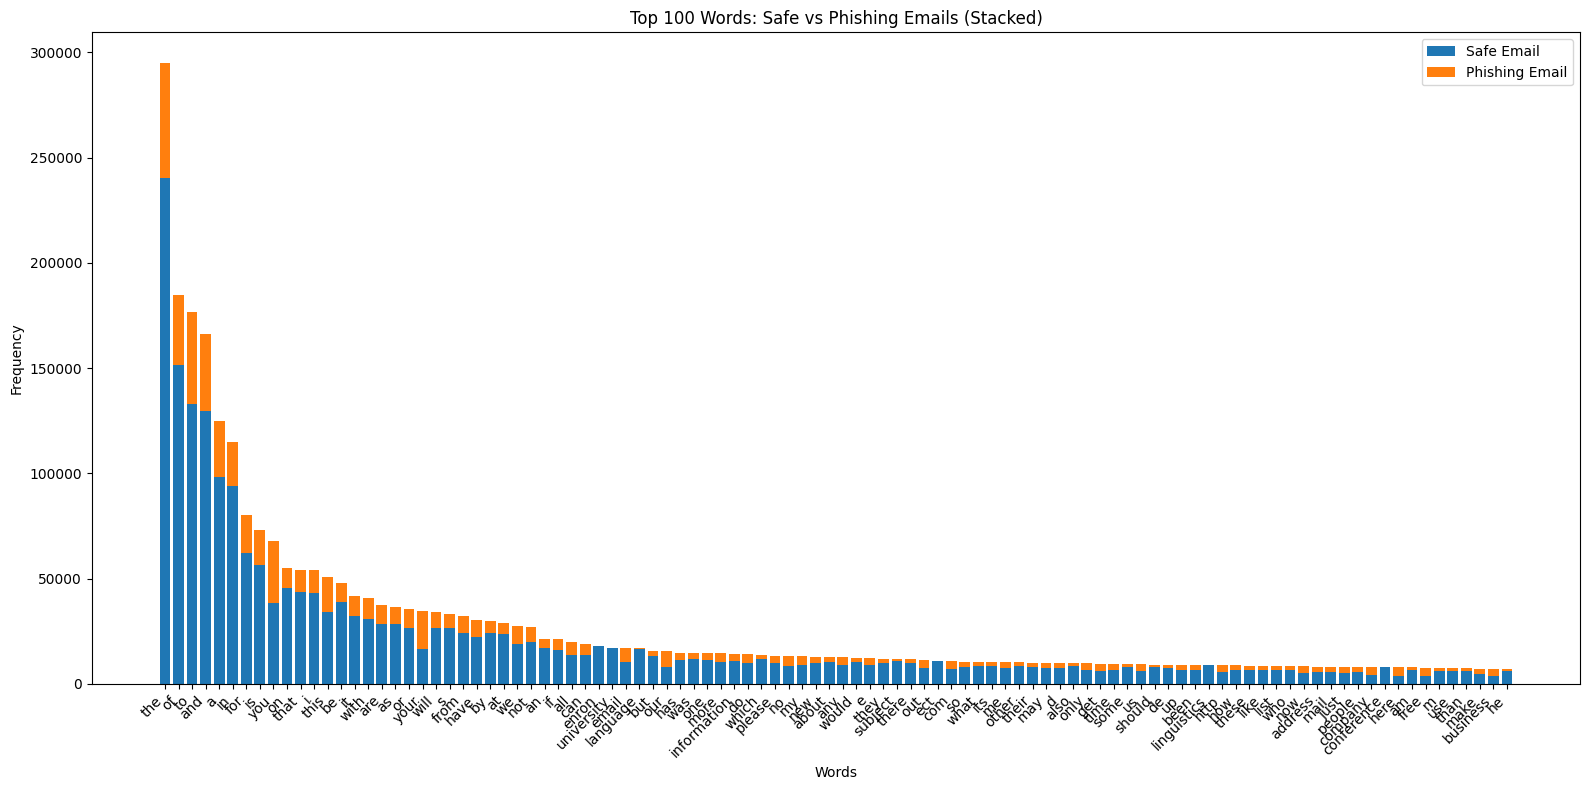

In [ ]:
# Select top N words by total count (safe + phishing)
top_n = 100
comparison_df["total_count"] = comparison_df["safe_count"] + comparison_df["phish_count"]
top_words = comparison_df.sort_values(by="total_count", ascending=False).head(top_n)

# Prepare figure like your previous layout
plt.figure(figsize=(16, 8))  # adjust size as needed

# Stacked bar
plt.bar(top_words["word"], top_words["safe_count"], label="Safe Email")
plt.bar(top_words["word"], top_words["phish_count"], bottom=top_words["safe_count"], label="Phishing Email")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title(f"Top {top_n} Words: Safe vs Phishing Emails")
plt.legend()
plt.tight_layout()
plt.show()

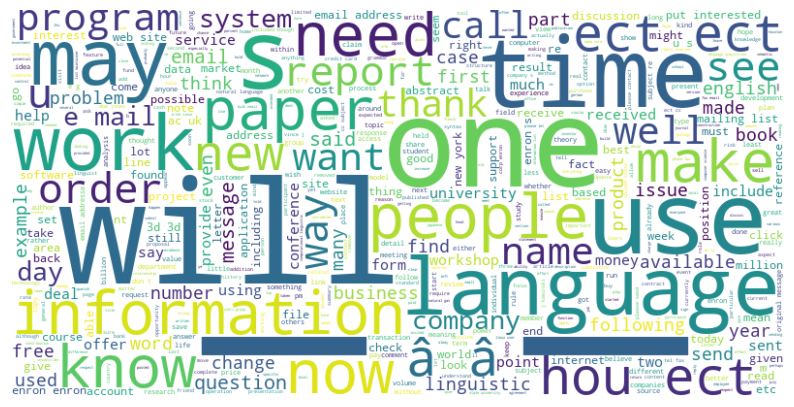

In [18]:
# Combine all emails into a single string
all_mails = " ".join(df['Email Text']) 

# Create a wordcloud object
word_cloud = WordCloud(stopwords=STOPWORDS, width=800,height=400,background_color='white',max_words=10000).generate(all_mails)

# Display the wordcloud
plt.figure(figsize=(10,6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## MODELING DATA

#### PROCESSING DATA

In [19]:
X = df['Email Text']
y = df['Email Type'].map({'Safe Email': 1, 'Phishing Email': 0})

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Text preprocessing and vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

#### GradientBoostingClassifier

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.3, random_state=42)
model_GradientBoosting = GradientBoostingClassifier(random_state=42)
model_GradientBoosting.fit(X_train, y_train)

y_pred = model_GradientBoosting.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9236031927023945
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1928
           1       0.91      0.97      0.94      3334

    accuracy                           0.92      5262
   macro avg       0.93      0.91      0.92      5262
weighted avg       0.93      0.92      0.92      5262



#### RandomForestClassifier

In [ ]:
model_RandomForest = RandomForestClassifier(random_state=42)
model_RandomForest.fit(X_train, y_train) 
y_pred = model_RandomForest.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))


Accuracy: 0.9722538958570885
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1928
           1       0.99      0.97      0.98      3334

    accuracy                           0.97      5262
   macro avg       0.97      0.97      0.97      5262
weighted avg       0.97      0.97      0.97      5262



#### SVC

In [ ]:
model_svc = SVC(random_state=42)
model_svc.fit(X_train, y_train)
y_pred = model_svc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.984416571645762
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1928
           1       0.99      0.99      0.99      3334

    accuracy                           0.98      5262
   macro avg       0.98      0.98      0.98      5262
weighted avg       0.98      0.98      0.98      5262

[[1881   47]
 [  35 3299]]


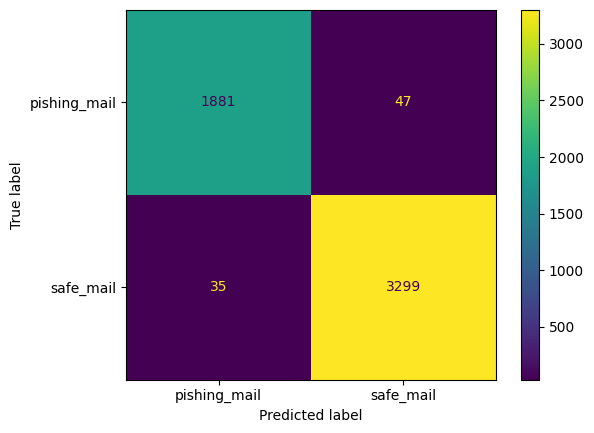

In [ ]:
clf_nav = confusion_matrix(y_test,y_pred)
cx_ = ConfusionMatrixDisplay(clf_nav,display_labels=['pishing_mail','safe_mail']).plot()
plt.show()

#### LogisticRegression

In [ ]:
model_LogisticRegression = LogisticRegression(max_iter=1000,penalty='l2')
model_LogisticRegression.fit(X_train, y_train)
y_pred = model_LogisticRegression.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9785252755606233
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1928
           1       0.98      0.99      0.98      3334

    accuracy                           0.98      5262
   macro avg       0.98      0.97      0.98      5262
weighted avg       0.98      0.98      0.98      5262



#### simple neural network

In [ ]:
# simple neural network
model_NN = MLPClassifier(hidden_layer_sizes=(10,), max_iter=800, random_state=42)

model_NN.fit(X_train, y_train)
y_pred = model_NN.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy) 
print(classification_report(y_test, y_pred))

Accuracy: 0.9771949828962372
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1928
           1       0.99      0.98      0.98      3334

    accuracy                           0.98      5262
   macro avg       0.97      0.98      0.98      5262
weighted avg       0.98      0.98      0.98      5262



#### DecisionTreeClassifier

In [ ]:
model_DecisionTree = DecisionTreeClassifier(random_state=42)
model_DecisionTree.fit(X_train, y_train) 
y_pred = model_DecisionTree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9228430254656025
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      1928
           1       0.95      0.93      0.94      3334

    accuracy                           0.92      5262
   macro avg       0.91      0.92      0.92      5262
weighted avg       0.92      0.92      0.92      5262



#### Naive bayes

In [ ]:
model_NaiveBayes = MultinomialNB()
model_NaiveBayes.fit(X_train, y_train)
y_pred = model_NaiveBayes.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred)) 

Accuracy: 0.9688331432915241
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1928
           1       0.97      0.98      0.98      3334

    accuracy                           0.97      5262
   macro avg       0.97      0.96      0.97      5262
weighted avg       0.97      0.97      0.97      5262



## CONCLUSION

In [ ]:
models = ['Boosting', 'Random Forest', 'SVM', 'Logistic Regression', 'Nueral Network', 'Decision Tree', 'Naive bayes']
accuracies = [92.36, 97.22, 98.44, 97.85, 97.71, 92.28, 96.88]

fig = px.bar(x=models, y=accuracies, labels={'x': 'Models', 'y': 'Accuracy'}, title="Performance of the models", text=accuracies)
fig.show()